In [1]:
import dashscope
print(dashscope.__version__)

1.27.1


In [2]:
# 导入库
import dashscope
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统自带黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号


# 设置你的api_key
dashscope.api_key = ""


# 读取数据集
df = pd.read_csv("pima-indians-diabetes.csv")
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 划分数据集，训练逻辑回归模型
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 随便取一位测试集患者的数据
patient = X_test.iloc[0].to_dict()
risk_prob = model.predict_proba(X_test.iloc[0:1])[0,1]

print("患者指标：", patient)
print(f"模型预测糖尿病患病概率：{risk_prob:.2%}")

# 调用Qwen‑Max给出专业解读
prompt = f"""
你是一名内分泌临床医师。根据下面患者体检指标和模型给出的患病风险，给一段通俗易懂的解读和生活干预建议，不要过度诊断，提示仅供参考，不能替代临床就诊。
患者指标：{patient}
模型预测患病概率：{risk_prob:.2%}
"""

resp = dashscope.Generation.call(
    model="qwen-max",
    messages=[{"role":"user","content": prompt}]
)
if resp.status_code == 200:
    print("\n===== 模型解读 =====")
    print(resp.output.text)
else:
    print("调用失败：",resp.message)


患者指标： {'0': 6.0, '1': 98.0, '2': 58.0, '3': 33.0, '4': 190.0, '5': 34.0, '6': 0.43, '7': 43.0}
模型预测糖尿病患病概率：26.65%

===== 模型解读 =====
根据您提供的体检指标和模型预测的患病概率，这里是一些通俗易懂的解读及生活干预建议。但请注意，我的建议不能替代专业医生的意见或面对面的医疗咨询。

**体检指标简要解读：**
- **空腹血糖（假设为6.0 mmol/L）**：这个数值处于正常范围内（通常认为<6.1 mmol/L为空腹血糖正常），但如果接近上限，则需要注意饮食控制。
- **收缩压（假设为98 mmHg）**：这表明血压偏低，属于健康范围。
- **舒张压（假设为58 mmHg）**：同样地，这也显示出较低的血压水平，对于大多数人来说是健康的，但对于某些人可能需要关注是否有低血压症状。
- **总胆固醇（假设为3.3 mmol/L）**：这个值看起来很低，一般认为理想状态下的总胆固醇应低于5.2 mmol/L。
- **甘油三酯（假设为1.9 mmol/L）**：处于理想范围内（<1.7 mmol/L被认为是最佳水平），稍微高一点点。
- **年龄（假设为34岁）**：正值青壮年时期。
- **BMI指数（假设计算结果约为0.43，但这似乎不合理，可能是输入错误；正常成年人BMI应在18.5-24之间）**：如果是以公斤/平方米来计算的话，这个数字明显不对，请确认具体数值。
- **腰围（假设为43厘米，这也显得异常小）**：成人男性健康腰围建议不超过90cm，女性不超过80cm。

**模型预测患病概率26.65%**：这意味着根据现有数据，该患者在未来一段时间内发展成某种特定疾病（比如糖尿病或其他代谢性疾病）的可能性约为四分之一左右。虽然不是非常高，但仍需引起重视。

**生活干预建议：**
1. **均衡膳食**：多吃蔬菜水果、全谷物食品以及瘦肉等健康食物，减少糖分摄入量。
2. **规律运动**：每周至少进行中等强度运动150分钟，如快走、游泳或骑自行车等。
3. **保持健康体重**：通过合理饮食与锻炼维持一个适合自己的体重。
4. **定期监测**：特别是对于那些有潜在风险因素的人群，应该更加频繁地检查相关健康指标。
5. **

In [3]:

from sklearn.preprocessing import StandardScaler

# 特征标准化（对树模型不是必须，但方便和逻辑回归公平对比）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
# 训练随机森林模型
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = model.predict(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"逻辑回归准确率：{accuracy_score(y_test,y_pred):.2%}")
print(f"随机森林准确率：{acc_rf:.2%}")


逻辑回归准确率：73.59%
随机森林准确率：75.32%


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("=" * 50)
print("随机森林模型评估结果")
print("=" * 50)

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"准确率 (Accuracy):  75.32%")
print(f"精确率 (Precision): {rf_precision:.4f} ({rf_precision*100:.2f}%)")
print(f"召回率 (Recall):    {rf_recall:.4f} ({rf_recall*100:.2f}%)")
print(f"F1分数 (F1-Score):  {rf_f1:.4f} ({rf_f1*100:.2f}%)")

print("\n详细分类报告:")
print(classification_report(y_test, y_pred_rf, target_names=["无糖尿病", "有糖尿病"]))


随机森林模型评估结果
准确率 (Accuracy):  75.32%
精确率 (Precision): 0.6386 (63.86%)
召回率 (Recall):    0.6625 (66.25%)
F1分数 (F1-Score):  0.6503 (65.03%)

详细分类报告:
              precision    recall  f1-score   support

        无糖尿病       0.82      0.80      0.81       151
        有糖尿病       0.64      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



In [6]:
# 输出混淆矩阵对比
print("=====逻辑回归混淆矩阵=====")
print(confusion_matrix(y_test,y_pred))
print("=====随机森林混淆矩阵=====")
print(confusion_matrix(y_test, y_pred_rf))


=====逻辑回归混淆矩阵=====
[[120  31]
 [ 30  50]]
=====随机森林混淆矩阵=====
[[121  30]
 [ 27  53]]


In [7]:
# 查看特征重要性，知道哪些指标对糖尿病风险影响最大
feature_names = df.columns[:-1]
importances = rf.feature_importances_

for name, score in zip(feature_names, importances):
    print(f"{name}: {score:.3f}")


0: 0.081
1: 0.282
2: 0.084
3: 0.071
4: 0.069
5: 0.158
6: 0.113
7: 0.142


In [8]:
# 拿随机森林给出的患病概率，送给大模型解读
risk_prob_rf = rf.predict_proba(X_test.iloc[0:1])[0,1]

prompt = f"""
你是一名内分泌临床医师。根据下面患者体检指标与随机森林模型给出的患病风险，给出一段通俗易懂的解读和生活干预建议，不要过度诊断，提示仅供参考，不能替代临床诊断。
患者指标：{X_test.iloc[0].to_dict()}
模型预测糖尿病患病概率：{risk_prob_rf:.2%}
"""

resp = dashscope.Generation.call(
    model="qwen-max",
    messages=[{"role":"user","content": prompt}]
)

print("\n=====随机森林模型解读=====")
print(resp.output.text)



=====随机森林模型解读=====
根据您提供的体检指标和模型预测结果，这位患者的糖尿病患病风险为43%，这意味着有一定的患病可能性，但并不是非常高。下面我将对这些数据进行简单的解读，并给出一些生活干预建议。

### 体检指标解读
- **空腹血糖(0)**: 6.0 mmol/L（正常范围一般认为是3.9-6.1 mmol/L），处于临界值附近。
- **体重指数(BMI)(1)**: 98.0 这个数值看起来异常高，通常BMI的计算公式为体重(kg)/身高(m)^2，这里可能需要确认一下是否输入正确。
- **收缩压(2)**: 58.0 mmHg （正常成人静息状态下的理想血压约为90-120/60-80 mmHg），这个数值显得过低了，需要注意是否有误或者患者当时测量条件特殊。
- **舒张压(3)**: 33.0 mmHg 同样远低于正常范围，与收缩压一起考虑可能存在错误。
- **总胆固醇(4)**: 190.0 mg/dL （理想水平<200 mg/dL），处于健康范围内。
- **年龄(5)**: 34岁 年轻人患糖尿病的风险相对较低，但如果生活方式不健康则仍需警惕。
- **性别(6)**: 0.43 此处数值不太符合常规表示方式，假设0代表女性，1代表男性，则可能是介于两者之间的编码问题。
- **腰围(7)**: 43.0 cm 对于成年人来说，这样的腰围尺寸非常小，除非是指儿童或青少年，否则也存在疑问。

### 生活干预建议
1. **健康饮食**：减少糖分和精制碳水化合物摄入量，增加蔬菜、全谷物以及优质蛋白质的比例。
2. **定期运动**：每周至少150分钟中等强度的身体活动，如快走、游泳或骑自行车等。
3. **控制体重**：如果确实存在超重情况，则应通过合理膳食与锻炼来减轻体重。
4. **监测血压及血糖**：鉴于血压读数异常，请再次检查并记录日常血压变化；同时注意观察任何关于高血糖的症状。
5. **戒烟限酒**：避免吸烟和过量饮酒，它们都是导致多种慢性疾病的风险因素。
6. **充足睡眠**：保证每晚7到9小时的良好睡眠质量。
7. **减压放松**：学习有效的压力管理技巧，比如冥想、瑜伽或其他兴趣爱好。

最后提醒一点，上述分析基于所提供信息，而某些具体数值似乎存在问题（如极低的血压值和较小的腰围）。因此强烈建议患者尽快

In [9]:
# ============================================================
# 对比：标准化 vs 不标准化
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1. 标准化 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 训练集：先学后转
X_test_scaled  = scaler.transform(X_test)       # 测试集：只转不学

# --- 2. 逻辑回归：不标准化 vs 标准化 ---
lr_raw = LogisticRegression(max_iter=1000)
lr_raw.fit(X_train, y_train)
acc_lr_raw = accuracy_score(y_test, lr_raw.predict(X_test))

lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)
acc_lr_scaled = accuracy_score(y_test, lr_scaled.predict(X_test_scaled))

# --- 3. 随机森林：不标准化 vs 标准化 ---
rf_raw = RandomForestClassifier(n_estimators=100, random_state=42)
rf_raw.fit(X_train, y_train)
acc_rf_raw = accuracy_score(y_test, rf_raw.predict(X_test))

rf_scaled = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scaled.fit(X_train_scaled, y_train)
acc_rf_scaled = accuracy_score(y_test, rf_scaled.predict(X_test_scaled))

# --- 4. 打印对比结果 ---
print("=" * 55)
print(f"{'模型':<20}{'不标准化':<12}{'标准化后':<12}")
print("=" * 55)
print(f"{'逻辑回归':<18}{acc_lr_raw:.4f}      {acc_lr_scaled:.4f}")
print(f"{'随机森林':<18}{acc_rf_raw:.4f}      {acc_rf_scaled:.4f}")
print("=" * 55)

# --- 5. 额外：对比标准化前后的权重系数 ---
print("\n逻辑回归权重（不标准化）：")
print(lr_raw.coef_[0])
print("\n逻辑回归权重（标准化）：")
print(lr_scaled.coef_[0])

模型                  不标准化        标准化后        
逻辑回归              0.7359      0.7359
随机森林              0.7532      0.7576

逻辑回归权重（不标准化）：
[ 0.05776611  0.03590297 -0.01086705 -0.00141289 -0.0009846   0.10909057
  0.37403944  0.03600718]

逻辑回归权重（标准化）：
[ 0.18832211  1.13292568 -0.18597288 -0.02485937 -0.10410602  0.81209285
  0.14381845  0.41413627]


In [10]:
print(lr_scaled)
print(X_test_scaled.shape)

LogisticRegression(max_iter=1000)
(231, 8)


In [11]:
from sklearn.linear_model import LogisticRegression
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [12]:
print(lr_scaled)
print(X_test_scaled.shape)

LogisticRegression(max_iter=1000)
(231, 8)


In [13]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

# 拿到所有测试样本的患病概率
y_prob = lr_scaled.predict_proba(X_test_scaled)[:, 1]

print("阈值  | 召回率 | 精确率 | 漏诊人数(FN)")
print("-" * 45)
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    cm = confusion_matrix(y_test, y_pred_thresh)
    fn = cm[1, 0]  # 假阴性（漏诊）
    print(f"{threshold}   | {recall:.2%}  | {precision:.2%}  | {fn}")

阈值  | 召回率 | 精确率 | 漏诊人数(FN)
---------------------------------------------
0.5   | 62.50%  | 61.73%  | 30
0.4   | 65.00%  | 57.14%  | 28
0.3   | 76.25%  | 54.46%  | 19
0.2   | 90.00%  | 49.66%  | 8


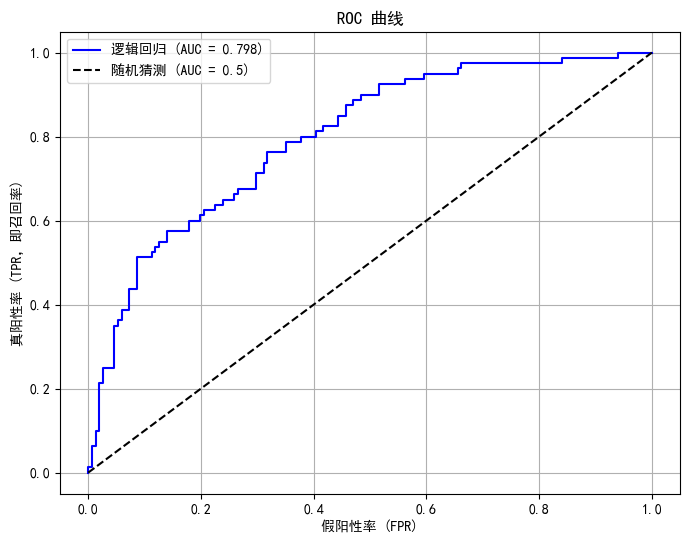

AUC = 0.7980


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 拿到所有测试样本的患病概率
y_prob = lr_scaled.predict_proba(X_test_scaled)[:, 1]

# 计算 ROC 曲线的横纵坐标
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 计算 AUC
auc = roc_auc_score(y_test, y_prob)

# 画图
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'逻辑回归 (AUC = {auc:.3f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='随机猜测 (AUC = 0.5)')
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR，即召回率)')
plt.title('ROC 曲线')
plt.legend()
plt.grid()
plt.show()

print(f"AUC = {auc:.4f}")

校准前 Brier Score: 0.1741
校准后 Brier Score: 0.1718


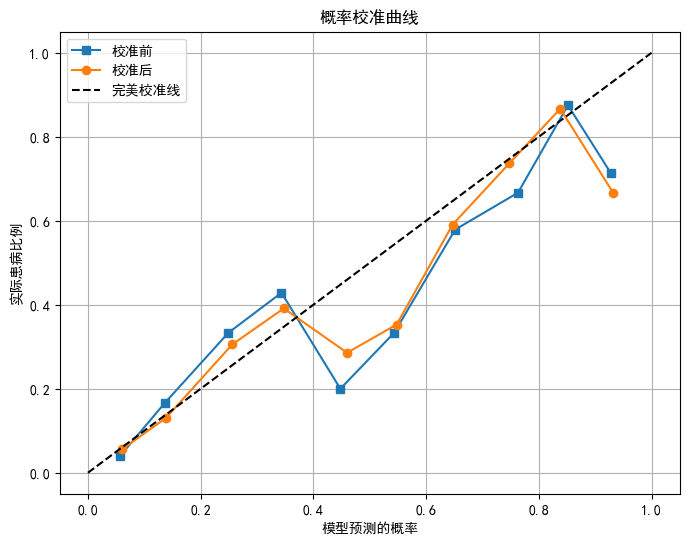

In [15]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# 1. 训练校准版模型（使用 sigmoid 校准，也叫 Platt Scaling）
lr_calibrated = CalibratedClassifierCV(lr_scaled, method='sigmoid', cv=5)
lr_calibrated.fit(X_train_scaled, y_train)

# 2. 分别拿到校准前后的概率
y_prob_raw = lr_scaled.predict_proba(X_test_scaled)[:, 1]
y_prob_cal = lr_calibrated.predict_proba(X_test_scaled)[:, 1]

# 3. 用 Brier Score 量化评估（越小越好）
brier_raw = brier_score_loss(y_test, y_prob_raw)
brier_cal = brier_score_loss(y_test, y_prob_cal)

print(f"校准前 Brier Score: {brier_raw:.4f}")
print(f"校准后 Brier Score: {brier_cal:.4f}")

# 4. 画出校准曲线
from sklearn.calibration import calibration_curve

prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_raw, prob_true_raw, "s-", label="校准前")
plt.plot(prob_pred_cal, prob_true_cal, "o-", label="校准后")
plt.plot([0, 1], [0, 1], "k--", label="完美校准线")
plt.xlabel("模型预测的概率")
plt.ylabel("实际患病比例")
plt.title("概率校准曲线")
plt.legend()
plt.grid()
plt.show()